In [2]:
import tensorflow as tf
#Load Dataset
IMG_SIZE = (128, 128)# نحدد حجم الصورة بحيث كله يكون نفس الحجم
BATCH_SIZE = 32# تحويل الصور لمجموعات بحيث كل مجموعه تحتوى على نفس عدد الصور

train_ds = tf.keras.utils.image_dataset_from_directory(# بيقرا الصور من الفولدر و بيسجلها فى متغير
    "Training",
    validation_split=0.2,# 80train w 20 validate عشان يخلى الموديل يتعلم و بعدين يتاكد هو اتعلم صح ولا بيحفظ
    subset="training",# بيقوله هات البيانات الخاصه بالتدريب 80
    seed=42, # عشان يطلع التقسيمه كل مره
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE#ياخد 32 صورةيحسب الخطأ نفسهثم يأخذ 32 أخرى


)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Training",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [83]:
#Dataset Summary
print("Number of classes:", len(class_names))
print("Classes:", class_names)

train_batches = tf.data.experimental.cardinality(train_ds).numpy()#بتستخم cardinality عشان نعرف عدد العناصر يلى موجودة 4480/32
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

Number of classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train batches: 140
Validation batches: 35
Test batches: 50


{'glioma': 1140, 'meningioma': 1125, 'notumor': 1100, 'pituitary': 1115}


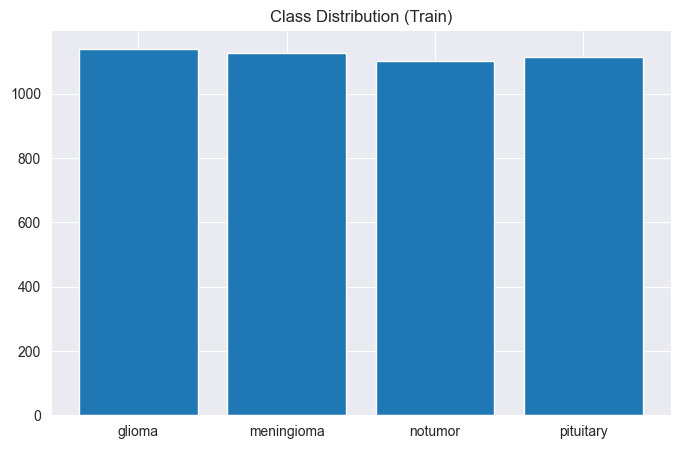

In [3]:
#Class Distribution Plot
import matplotlib.pyplot as plt

class_counts = {name: 0 for name in class_names}# اعملى dictionary فيه مل اسم كلاس و عدد يبدا من الصفر

for images, labels in train_ds:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1
print(class_counts)

plt.figure(figsize=(8,5))#width =8 w length= 5
plt.bar(class_counts.keys(), class_counts.values())# key esm el class w value 3dd
plt.title("Class Distribution (Train)")
plt.xticks(rotation=30)# ميل اسماء الكلاسات
plt.show()

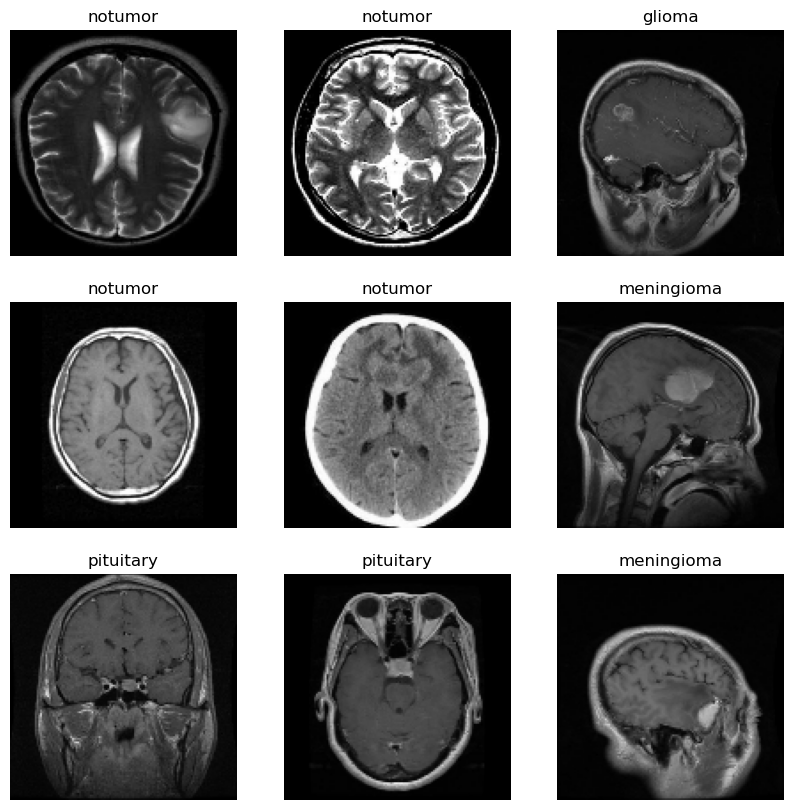

In [85]:
#Sample Images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):#معناها خد اول batch بس
    for i in range(9):
        ax = plt.subplot(3,3,i+1)# اعمل grid 3x3 w i+1 rakam el makan yali han7ot feh el صور

        plt.imshow(images[i].numpy().astype("uint8"))# نعرض الصور
        # image[i] الصور من batch
        #numpy نحولها الارقام
        #astype نخليها الاولوان صحيحه
        plt.title(class_names[labels[i]])
        plt.axis("off")#  شيلالخطوط و الارقام حولين الصور

In [86]:
#Duplicate Check
import os

all_files = []# نخزن فيها اسماء كل ملفات (الصور)
for root, dirs, files in os.walk("Training"):# os.walk بتلف على كل فولدرات و فولدر يلى جوه كل فولدر يلى هى صور
    for file in files:# بنلف على كل الفولدرات يلى جوة الفولجر الحالى
        all_files.append(file) # بتضيف اسم الملف للقائمه

print("Total files:", len(all_files))
print("Unique files:", len(set(all_files)))

Total files: 5600
Unique files: 5600


In [87]:
#Sample Count Check
#image .shape (32,128,128,3)# 32 el batch w 128 height pixel w 128 width w 3 RGB red green blue
# image.shape[0] بتقول
train_count = sum([images.shape[0] for images, labels in train_ds])# بتقول عدد الصور داخل كل batch
val_count = sum([images.shape[0] for images, labels in val_ds])
test_count = sum([images.shape[0] for images, labels in test_ds])

print("Train samples:", train_count)
print("Validation samples:", val_count)
print("Test samples:", test_count)

Train samples: 4480
Validation samples: 1120
Test samples: 1600


* Since the dataset consists of standard image files loaded via image_dataset_from_directory, there are no missing tabular values. We checked for duplicated filenames and found all files are unique. No extreme outliers in pixel intensities exist as all images were standard RGB arrays and properly rescaled to the [0, 1] range."

In [88]:
#Normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)#وظيفتها تحول قيم الصور من 0:255الى 0:1عشان الموديل يتعلم افضل لما يكون القيم صغيرة و منظمه

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))# el x el photo w y labels
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [89]:
#Performance Optimization +
AUTOTUNE = tf.data.AUTOTUNE# بيحدد تلقائيا سرعه تحميل الداتا
#Auto يخليه يختار لوحده W tune يظبط الاداء
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
#cache bit5zn e;l data fl memory
# shuufle bt5lt el data
# prefetech يخلى الجهاز يعنل batch جديده اثناء تدريب
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [90]:
from tensorflow.keras import layers, models

input_shape = (128, 128, 3)
num_classes = len(class_names)

ffnn_model = models.Sequential([# بنبدا نبنى موديل sequential طبقه فوق طبقه
    layers.Input(shape=input_shape), 

    layers.Flatten(),# بتحول الصور على شكل vectot  على خط واحدعشان ال dense يفهمها

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

In [91]:
ffnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [92]:
early_stop_ffnn = tf.keras.callbacks.EarlyStopping(# بنحط قانون ايقاف تلقائى للتدريب
    monitor='val_loss',# راقب الvalidation loss نشوف الخطا على بيانات ال Valdition
    patience=5,#استنى خمسه epoch  لو خلا خمس دورات مفيش تحسن val_loss يبقى وقف التدريب
    restore_best_weights=True#📌 مش آخر epoch، لكن أفضل epoch حصل فيه أقل val_loss
    #"ارجع لأفضل نسخة من الموديل
)

In [93]:
import time

start = time.time()# سجل وقت البدايه قبل التدريب

history_ffnn = ffnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_ffnn]
)

end = time.time()

ffnn_training_time = end - start
ffnn_epoch_time = ffnn_training_time / len(history_ffnn.history['loss'])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.4475 - loss: 2.5965 - val_accuracy: 0.6500 - val_loss: 0.9133
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.5732 - loss: 0.9805 - val_accuracy: 0.6679 - val_loss: 0.8916
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.5085 - loss: 1.0934 - val_accuracy: 0.6625 - val_loss: 0.9293
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.5752 - loss: 0.9977 - val_accuracy: 0.6339 - val_loss: 0.9165
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 181ms/step - accuracy: 0.6143 - loss: 0.9044 - val_accuracy: 0.7071 - val_loss: 0.7529
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.6382 - loss: 0.8748 - val_accuracy: 0.6857 - val_loss: 0.7919
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.6491 - loss: 0.8410 - val_accuracy: 0.7161 - val_loss: 0.6666
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - accuracy: 0.6632 - loss: 0

In [94]:
cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),# بيطلع المميزات من الصور
    layers.MaxPooling2D(),# بيصغر الصور و بيحتفظ باهم جزء فيها بياخد أكبر رقم
    #👉 "Conv2D بيشوف تفاصيل الصورة، وMaxPooling بيقلل الحجم ويحتفظ بالمهم"

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

In [95]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [96]:
early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [97]:
start = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_cnn]
)

end = time.time()

cnn_training_time = end - start
cnn_epoch_time = cnn_training_time / len(history_cnn.history['loss'])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 50s 340ms/step - accuracy: 0.6788 - loss: 0.7749 - val_accuracy: 0.8313 - val_loss: 0.4472
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 338ms/step - accuracy: 0.8333 - loss: 0.4391 - val_accuracy: 0.8848 - val_loss: 0.3199
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.8797 - loss: 0.3211 - val_accuracy: 0.9018 - val_loss: 0.2568
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.9147 - loss: 0.2339 - val_accuracy: 0.9098 - val_loss: 0.2550
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.9469 - loss: 0.1550 - val_accuracy: 0.9286 - val_loss: 0.1807
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.9558 - loss: 0.1248 - val_accuracy: 0.9464 - val_loss: 0.1692
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 50s 359ms/step - accuracy: 0.9679 - loss: 0.0936 - val_accuracy: 0.9268 - val_loss: 0.2263
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 48s 342ms/step - accuracy: 0.9741 - loss: 0

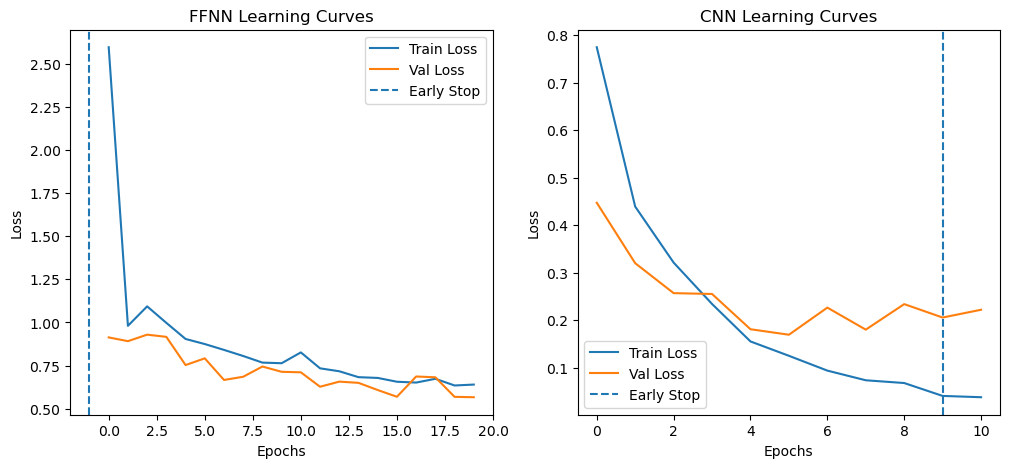

In [98]:
# FFNN history
ffnn_loss = history_ffnn.history['loss']# دة بيجيب الخسارة اثناء التدريب  Train
ffnn_val_loss = history_ffnn.history['val_loss']# دة بيجيب الخسارة على على بيانات التحقق
ffnn_stop_epoch = early_stop_ffnn.stopped_epoch #  رقم ال epoch يلى وقف عندها


# CNN history
cnn_loss = history_cnn.history['loss']
cnn_val_loss = history_cnn.history['val_loss']
cnn_stop_epoch = early_stop_cnn.stopped_epoch

epochs_ffnn = range(len(ffnn_loss))
epochs_cnn = range(len(cnn_loss))

plt.figure(figsize=(12,5))

# FFNN
plt.subplot(1,2,1)#1 row w 2 column w هنبدا بالشكل الاول
plt.plot(epochs_ffnn, ffnn_loss, label='Train Loss')
plt.plot(epochs_ffnn, ffnn_val_loss, label='Val Loss')

plt.axvline(x=ffnn_stop_epoch-1, linestyle='--', label='Early Stop')
plt.title("FFNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# CNN
plt.subplot(1,2,2)
plt.plot(epochs_cnn, cnn_loss, label='Train Loss')
plt.plot(epochs_cnn, cnn_val_loss, label='Val Loss')
plt.axvline(x=cnn_stop_epoch-1, linestyle='--', label='Early Stop')
plt.title("CNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [99]:
ffnn_stop_epoch = early_stop_ffnn.stopped_epoch
cnn_stop_epoch = early_stop_cnn.stopped_epoch

print("FFNN stopped at epoch:", ffnn_stop_epoch)
print("CNN stopped at epoch:", cnn_stop_epoch)


FFNN stopped at epoch: 0
CNN stopped at epoch: 10


### Overfitting Analysis
The FFNN model showed signs of overfitting, as the training loss decreased while the validation loss remained higher and less stable.
In contrast, the CNN model demonstrated better generalization, with a smaller gap between training and validation loss, indicating improved performance on unseen data.

### Regularization (Dropout)
Dropout was applied as a regularization technique to reduce overfitting in both models.
By randomly deactivating a portion of neurons during training, dropout prevents the model from relying too heavily on specific features.
This helped improve validation performance and enhanced the model’s generalization ability.

Without dropout, the model tends to memorize the training data

#### L1/L2 regularization was not applied in this project. Instead, dropout was used as an effective regularization technique.

In [100]:
# Evaluate models on test set
ffnn_test_loss, ffnn_test_acc = ffnn_model.evaluate(test_ds)# موديل هيغلط قد ايه و هيصلح قد ايه

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds)

print("FFNN Test Accuracy:", ffnn_test_acc)
print("CNN Test Accuracy:", cnn_test_acc)

#F1-Score for FFNN
from sklearn.metrics import classification_report

y_true = []# الاجابات الصحيحه
y_pred = []# توقع المودييل

for images, labels in test_ds:
    preds = ffnn_model.predict(images)# الموديل بيحاول يتوقع الصورة
    preds = preds.argmax(axis=1)# تحويل الاحتالات الارقام و نختار الاعلى

    y_true.extend(labels.numpy())# نجمع الاجاباات الصحيحه
    y_pred.extend(preds)# نجمع توقعات الموديل
    # extendيعنى ضيف قائمه لقائمه

print("FFNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

#F1-Score for CNN
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = cnn_model.predict(images)
    preds = preds.argmax(axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("CNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6988 - loss: 1.0790
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8806 - loss: 0.9035
FFNN Test Accuracy: 0.6987500190734863
CNN Test Accuracy: 0.8806250095367432
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━

#### In medical imaging tasks like Brain Tumor Classification, F1-Score is crucial alongside Accuracy because False Negatives (missing a tumor) are highly critical. Therefore, we evaluated both metrics.
* In addition to accuracy, F1-score was used to evaluate model performance. The CNN model achieved higher F1-scores across most classes, indicating better overall performance.

* Although the dataset is balanced, F1-score was also used as an additional evaluation metric for a more comprehensive performance analysis.

In [101]:
# Results

print("FFNN Total Training Time:", round(ffnn_training_time, 2), "seconds")# تقريب الوقت لتدريب الموديل رقمين بعد العلامه
print("FFNN Avg Epoch Time:", round(ffnn_epoch_time, 2), "seconds")

print("\nCNN Total Training Time:", round(cnn_training_time, 2), "seconds")
print("CNN Avg Epoch Time:", round(cnn_epoch_time, 2), "seconds")

FFNN Total Training Time: 540.83 seconds
FFNN Avg Epoch Time: 27.04 seconds

CNN Total Training Time: 561.67 seconds
CNN Avg Epoch Time: 51.06 seconds


In [102]:
# Count Test Samples

num_samples = sum(len(images) for images, labels in test_ds)

# FFNN Inference Speed

start = time.time()

ffnn_model.predict(test_ds)

end = time.time()

ffnn_inference_time = end - start
ffnn_speed = num_samples / ffnn_inference_time

# CNN Inference Speed

start = time.time()

cnn_model.predict(test_ds)

end = time.time()

cnn_inference_time = end - start
cnn_speed = num_samples / cnn_inference_time

# Results

print("FFNN Inference Time:", round(ffnn_inference_time, 2), "seconds")
print("FFNN Speed:", round(ffnn_speed, 2), "samples/sec")

print("\nCNN Inference Time:", round(cnn_inference_time, 2), "seconds")
print("CNN Speed:", round(cnn_speed, 2), "samples/sec")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step
FFNN Inference Time: 1.2 seconds
FFNN Speed: 1333.94 samples/sec

CNN Inference Time: 4.51 seconds
CNN Speed: 354.79 samples/sec


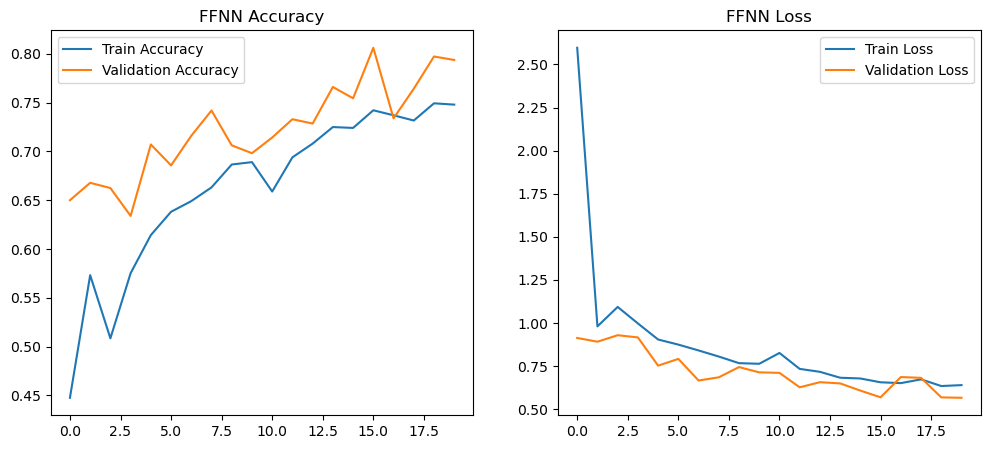

In [103]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_ffnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_ffnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FFNN Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ffnn.history['loss'], label='Train Loss')
plt.plot(history_ffnn.history['val_loss'], label='Validation Loss')
plt.title('FFNN Loss')
plt.legend()

plt.show()

* The FFNN learning curves indicate a noticeable gap between training and validation performance. Training accuracy steadily increased across epochs, while validation accuracy remained lower and showed fluctuations instead of consistent improvement.

* Training loss continuously decreased, whereas validation loss stayed higher and slightly increased during later epochs. This suggests that the model learned the training data effectively but had limited generalization ability on unseen validation samples, indicating overfitting.

  Model  Accuracy      Loss  Training Time (sec)  Epoch Time (sec)  \
0  FFNN  0.698750  1.079007           540.828074         27.041404   
1   CNN  0.880625  0.903548           561.672906         51.061173   

   Inference Speed (samples/sec)  
0                    1333.938608  
1                     354.789673  


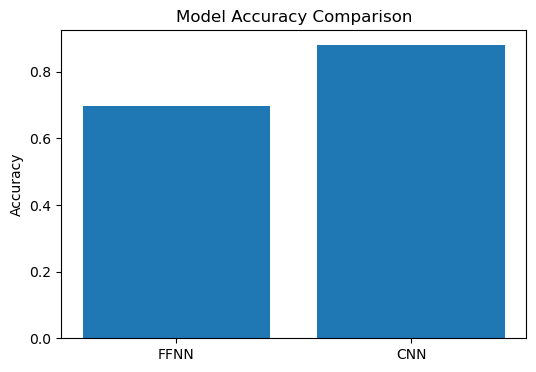

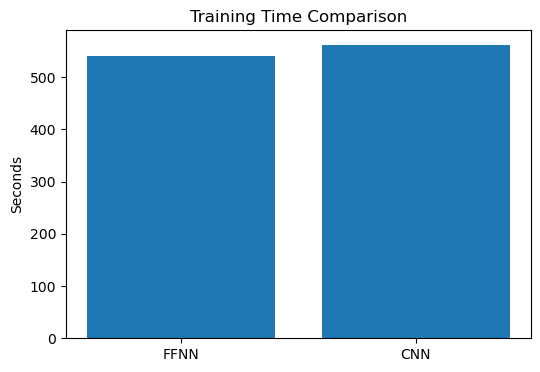

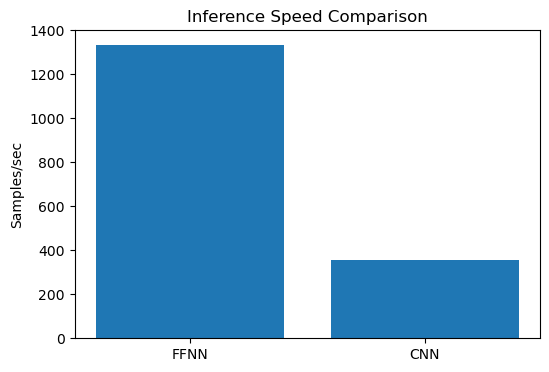

In [104]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["FFNN", "CNN"],
    "Accuracy": [ffnn_test_acc, cnn_test_acc],
    "Loss": [ffnn_test_loss, cnn_test_loss],
    "Training Time (sec)": [ffnn_training_time, cnn_training_time],
    "Epoch Time (sec)": [ffnn_epoch_time, cnn_epoch_time],
    "Inference Speed (samples/sec)": [ffnn_speed, cnn_speed]
})

print(results)

# Accuracy Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Training Time Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Training Time (sec)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

# Inference Speed Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Inference Speed (samples/sec)"])
plt.title("Inference Speed Comparison")
plt.ylabel("Samples/sec")
plt.show()

### Comparison Summary

The CNN model achieved higher accuracy and better generalization compared to FFNN. 
Although CNN required slightly more training time, it provided better performance on unseen data. 
FFNN was faster but suffered from overfitting and lower accuracy.

## Optimization Experiments

### Experiment 1: High Learning Rate

In [105]:
experiment1_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

experiment1_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment1 = experiment1_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 257ms/step - accuracy: 0.5609 - loss: 1.2043 - val_accuracy: 0.7339 - val_loss: 0.6443
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 269ms/step - accuracy: 0.7935 - loss: 0.5131 - val_accuracy: 0.7536 - val_loss: 0.6110
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 256ms/step - accuracy: 0.8801 - loss: 0.3223 - val_accuracy: 0.8143 - val_loss: 0.5677
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 255ms/step - accuracy: 0.9087 - loss: 0.2354 - val_accuracy: 0.7973 - val_loss: 0.5329
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 255ms/step - accuracy: 0.9536 - loss: 0.1420 - val_accuracy: 0.8473 - val_loss: 0.5990


* Using a high learning rate (0.01) resulted in unstable training and lower validation performance, indicating that a smaller learning rate is more suitable.

### Experiment 2: Without Dropout

In [106]:
experiment2_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

experiment2_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment2 = experiment2_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 257ms/step - accuracy: 0.7127 - loss: 0.7319 - val_accuracy: 0.7955 - val_loss: 0.4746
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step - accuracy: 0.8790 - loss: 0.3275 - val_accuracy: 0.8875 - val_loss: 0.3170
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.9362 - loss: 0.1744 - val_accuracy: 0.9116 - val_loss: 0.2989
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.9643 - loss: 0.1002 - val_accuracy: 0.9161 - val_loss: 0.3368
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step - accuracy: 0.9819 - loss: 0.0615 - val_accuracy: 0.9045 - val_loss: 0.3273


* Removing dropout led to higher training accuracy but worse validation performance, indicating overfitting.

### Experiment 3: Lower Learning Rate

In [107]:
experiment3_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

experiment3_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment3 = experiment3_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 260ms/step - accuracy: 0.6641 - loss: 0.8418 - val_accuracy: 0.7821 - val_loss: 0.5543
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.8121 - loss: 0.5039 - val_accuracy: 0.8179 - val_loss: 0.4541
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 260ms/step - accuracy: 0.8672 - loss: 0.3860 - val_accuracy: 0.8518 - val_loss: 0.4220
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.8940 - loss: 0.3058 - val_accuracy: 0.8804 - val_loss: 0.3363
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 260ms/step - accuracy: 0.9105 - loss: 0.2578 - val_accuracy: 0.8813 - val_loss: 0.3269


* Using a smaller learning rate (0.0001) resulted in more stable training and improved validation performance. 

* The model was able to converge more smoothly compared to a higher learning rate, leading to better generalization on unseen data.

### Experiment 4: Data Augmentation

In [108]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

experiment4_cnn = models.Sequential([
    layers.Input(shape=(128,128,3)),
    
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

experiment4_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment4 = experiment4_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 281ms/step - accuracy: 0.6143 - loss: 0.8957 - val_accuracy: 0.7571 - val_loss: 0.6158
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.7549 - loss: 0.6247 - val_accuracy: 0.8080 - val_loss: 0.4743
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.8016 - loss: 0.5170 - val_accuracy: 0.8411 - val_loss: 0.3986
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.8237 - loss: 0.4580 - val_accuracy: 0.8821 - val_loss: 0.3540
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.8335 - loss: 0.4182 - val_accuracy: 0.8991 - val_loss: 0.2957
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.8482 - loss: 0.3803 - val_accuracy: 0.8607 - val_loss: 0.3676
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.8629 - loss: 0.3498 - val_accuracy: 0.8714 - val_loss: 0.3341
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 275ms/step - accuracy: 0.8717 - loss: 0

* Data augmentation techniques such as random flipping and rotation were applied to increase data diversity and reduce overfitting. This helped improve the model's generalization on unseen data.

### Why Experiments Were Conducted on CNN Only

Experiments were mainly conducted on the CNN model because it is more suitable for image data and has higher capacity for learning complex spatial features. 

On the other hand, FFNN is considered a baseline model with limited ability to capture image patterns, so extensive optimization on it would not significantly improve performance.

Therefore, optimization efforts were focused on CNN to achieve better results and meaningful improvements.

## These experiments demonstrate how hyperparameter tuning significantly impacts model performance.